In [ ]:
import pandas as pd
import numpy as np
from FlagEmbedding import BGEM3FlagModel
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


Stowrzymy konkurencyjne podejście, gdzie uwzględnimy embeddingi oryginalnych tresci artykułów. Użyjemy do tego modelu `BAAI/bge-small-en-v1.5`.

In [105]:
data = pd.read_csv('../data/processed/final_dataset_with_features.csv')

In [106]:
emb_model = BGEM3FlagModel('BAAI/bge-small-en-v1.5',  
                       use_fp16=True)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1518.16it/s]


In [16]:
X_emb = emb_model.encode(data['text'].tolist(), batch_size=16)

Inference Embeddings: 100%|██████████| 576/576 [15:29<00:00,  1.61s/it]


In [107]:
data['embedding'] = list(X_emb['dense_vecs'])

Wymiar embeddingów:

In [108]:
data['embedding'][0].shape

(384,)

In [109]:
Y = data['label']
X = data.drop(columns=['label','text','chunk_count', 'source_category'])

In [110]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y,
    test_size=0.20,
    random_state=42,
    stratify=data[['label', 'source_category']]
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [111]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "XGBoost":             xgb.XGBClassifier(random_state=42, n_jobs=-1),
    "Random Forest":       RandomForestClassifier(random_state=42, n_jobs=-1),
    "SVM":                 SVC(kernel='rbf', random_state=42, probability=True),
    "MLP":                 MLPClassifier(random_state=42),
}

In [112]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [129]:
X_train_emb_matrix = np.array(X_train['embedding'].tolist())
X_valid_emb_matrix = np.array(X_valid['embedding'].tolist())
X_test_emb_matrix  = np.array(X_test['embedding'].tolist())

In [115]:
results = []

for name, model in models.items():
    print(f"Trenuję: {name}...")
    
    cv_f1 = cross_val_score(
        model, X_train_emb_matrix, y_train,
        cv=CV, scoring='f1', n_jobs=-1
    ).mean()
 
    model.fit(X_train_emb_matrix, y_train)
    
    y_valid_pred = model.predict(X_valid_emb_matrix)
 
    results.append({
        'Model': name,
        'CV F1': round(cv_f1, 3),
        'Valid F1': round(f1_score(y_valid, y_valid_pred), 3),
        'Valid Precision': round(precision_score(y_valid, y_valid_pred), 3),
        'Valid Recall': round(recall_score(y_valid, y_valid_pred), 3),
        'Valid Accuracy': round(accuracy_score(y_valid, y_valid_pred), 3),
    })

Trenuję: Logistic Regression...
Trenuję: XGBoost...
Trenuję: Random Forest...
Trenuję: SVM...


c:\Users\gabri\Desktop\article-credibility\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Trenuję: MLP...


c:\Users\gabri\Desktop\article-credibility\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [116]:
results_df = pd.DataFrame(results).sort_values('Valid F1', ascending=False).reset_index(drop=True)

In [117]:
results_df

,Model,CV F1,Valid F1,Valid Precision,Valid Recall,Valid Accuracy
0,SVM,0.945,0.946,0.961,0.932,0.946
1,MLP,0.943,0.941,0.941,0.941,0.939
2,Logistic Regression,0.927,0.927,0.945,0.909,0.926
3,XGBoost,0.924,0.923,0.945,0.903,0.923
4,Random Forest,0.908,0.909,0.947,0.873,0.910


Modele baselinowe wytrenowane na gęstych embeddingach osiągają o kilk pp. wyższe wyniki metryk wyliczonych zarówno w oparciu o crossvalidation oraz zbiór walidacyjny. Modele również nie są przetreniwane. Najgorsze, czego można było się spodziewać w przypadku modelowania *dense vector*, są modele drzewiaste. 

Wykorzystamy te modele bazowe do stworzenia modele stacking.

In [118]:
estimators = [(name.lower().replace(" ", "_"), model) for name, model in models.items()]

In [121]:
meta_learner = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
 
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_learner,
    cv=5,
    passthrough=False,
    n_jobs=-1
)


In [122]:
stacking_model.fit(X_train_emb_matrix, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('logistic_regression', ...), ('xgboost', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[LogisticRegre...ndom_state=42), XGBClassifier...ree=None, ...), RandomForestC...ndom_state=42), SVC(probabili...ndom_state=42), ...]"
final_estimator_ final_estimator_: estimatorThe classifier fit on the output of `estimators_` and responsible forfinal predictions.,LogisticRegression

In [123]:
val_preds = stacking_model.predict(X_valid_emb_matrix)
val_proba = stacking_model.predict_proba(X_valid_emb_matrix)[:, 1]

In [124]:
best_model_name = results_df.iloc[0]['Model']
best_model      = models[best_model_name]

best_proba      = best_model.predict_proba(X_valid_emb_matrix)[:, 1]
best_preds      = best_model.predict(X_valid_emb_matrix)
 
comparison = pd.DataFrame([
    {
        "Model":     best_model_name,
        "Valid F1":  round(f1_score(y_valid, best_preds), 3),
        "Precision": round(precision_score(y_valid, best_preds), 3),
        "Recall":    round(recall_score(y_valid, best_preds), 3),
        "Accuracy":  round(accuracy_score(y_valid, best_preds), 3),
    },
    {
        "Model":     "Stacking",
        "Valid F1":  round(f1_score(y_valid, val_preds), 3),
        "Precision": round(precision_score(y_valid, val_preds), 3),
        "Recall":    round(recall_score(y_valid, val_preds), 3),
        "Accuracy":  round(accuracy_score(y_valid, val_preds), 3),
    }
])
print(comparison)


      Model  Valid F1  Precision  Recall  Accuracy
0       SVM     0.946      0.961   0.932     0.946
1  Stacking     0.944      0.949   0.939     0.942


Oba modele osiągają bardzo podobne wartości metryk oceny jakości klasyfiakcji.

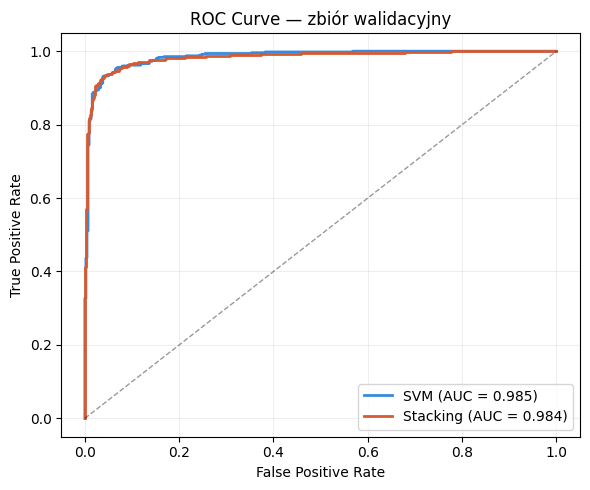

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
 
for name, proba, color in [
    (best_model_name, best_proba, "#378ADD"),
    ("Stacking",      val_proba,  "#D85A30"),
]:
    fpr, tpr, _ = roc_curve(y_valid, proba)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC = {roc_auc:.3f})")
 
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — zbiór walidacyjny")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


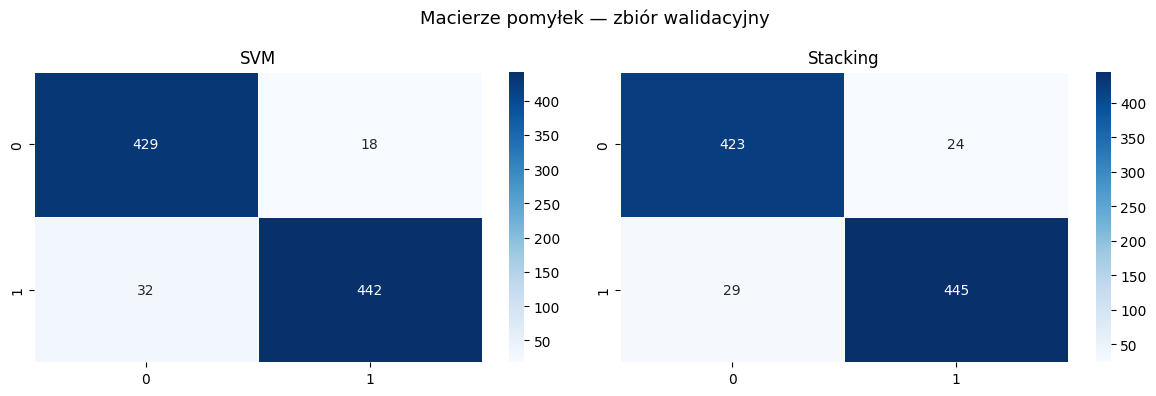

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Macierze pomyłek — zbiór walidacyjny", fontsize=13)
 
for ax, (name, preds) in zip(axes, {best_model_name: best_preds, "Stacking": val_preds}.items()):
    cm = confusion_matrix(y_valid, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                linewidths=0.5)
    ax.set_title(name)
 
plt.tight_layout()
plt.show()


In [130]:
test_models = {
    "SVM":    best_model.predict(X_test_emb_matrix),
    "Stacking Classifier": stacking_model.predict(X_test_emb_matrix),
}

In [131]:
pd.DataFrame([
    {
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, preds), 3),
        "F1":        round(f1_score(y_test, preds), 3),
    }
    for name, preds in test_models.items()
])

,Model,Accuracy,F1
0,SVM,0.946,0.947
1,Stacking Classifier,0.950,0.951


Ponownie model ensembe okazuje się być lepszy od modelu pojedynczego. Zastosowanie zaawansowanych embeddingów, które oddają znaczenie sematyczne tekstów poprawiło jakość predykcji względem modelu prostszego, opartego o ekstrakcję cech artykułów, o około 4 pp. (różnica w *F1-Score*). Natomiast dużą przewagą poddejścia zastosowanego w notatniku `modelling.ipynb` jest **wyjaśnialność** - poprzez analizę z wykorzystaniem metod taki jak *SHAP* (analiza z poziomu meta learnera lub poszczególnych modeli składowych), jesteśmy potencjalnie w stanie zrozumieć dlaczego model podjął daną decyję.

In [ ]:
#joblib.dump(stacking_model, '../models/stacking_model.joblib')

['../models/stacking_model.joblib']